In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_df = pd.read_csv("/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/train-small.csv")
valid_df = pd.read_csv("/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/valid-small.csv")

test_df = pd.read_csv("/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/test.csv")

train_df.head()

,Image,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,PatientId,Pleural_Thickening,Pneumonia,Pneumothorax
0,00008270_015.png,0,0,0,0,0,0,0,0,0,0,0,8270,0,0,0
1,00029855_001.png,1,0,0,0,1,0,0,0,1,0,0,29855,0,0,0
2,00001297_000.png,0,0,0,0,0,0,0,0,0,0,0,1297,1,0,0
3,00012359_002.png,0,0,0,0,0,0,0,0,0,0,0,12359,0,0,0
4,00017951_001.png,0,0,0,0,0,0,0,0,1,0,0,17951,0,0,0


In [4]:

labels = ['Cardiomegaly',
          'Emphysema',
          'Effusion',
          'Hernia',
          'Infiltration',
          'Mass',
          'Nodule',
          'Atelectasis',
          'Pneumothorax',
          'Pleural_Thickening',
          'Pneumonia',
          'Fibrosis',
          'Edema',
          'Consolidation']

In [5]:
print("Sample data count :")
count = 0
for label in labels:
    count += train_df[label].value_counts()[1]
    print(f"There are {train_df[label].value_counts()[1]} samples of disease {label}.")

print(f"There are {count} samples of disease.")
noData = len(train_df["PatientId"]) - count
print(f"There are {noData} samples of no disease.")

Sample data count :
There are 20 samples of disease Cardiomegaly.
There are 13 samples of disease Emphysema.
There are 128 samples of disease Effusion.
There are 2 samples of disease Hernia.
There are 175 samples of disease Infiltration.
There are 45 samples of disease Mass.
There are 54 samples of disease Nodule.
There are 106 samples of disease Atelectasis.
There are 38 samples of disease Pneumothorax.
There are 21 samples of disease Pleural_Thickening.
There are 10 samples of disease Pneumonia.
There are 14 samples of disease Fibrosis.
There are 16 samples of disease Edema.
There are 33 samples of disease Consolidation.
There are 675 samples of disease.
There are 325 samples of no disease.


In [6]:
def check_for_leakage(df1, df2, patient_col):
    """
    Return True if there any patients are in both df1 and df2.

    Args:
        df1 (dataframe): dataframe describing first dataset
        df2 (dataframe): dataframe describing second dataset
        patient_col (str): string name of column with patient IDs

    Returns:
        leakage (bool): True if there is leakage, otherwise False
    """
    #Converting datalist into frame to get unique patient IDs
    df1_patients_unique = set(df1[patient_col])
    df2_patients_unique = set(df2[patient_col])

    #Finding the intersection of both sets to check for leakage
    patients_in_both_groups = list(df1_patients_unique.intersection(df2_patients_unique))

    # leakage contains true if there is patient overlap, otherwise false.
    leakage = True if len(patients_in_both_groups) > 0 else False  # boolean (true if there is at least 1 patient in both groups)

    return leakage

In [7]:
print("test case 1")
df1 = pd.DataFrame({'patient_id': [0, 1, 2]})
df2 = pd.DataFrame({'patient_id': [2, 3, 4]})
print("df1")
print(df1)
print("df2")
print(df2)
print(f"leakage output: {check_for_leakage(df1, df2, 'patient_id')}")
print("-------------------------------------")
print("test case 2")
df1 = pd.DataFrame({'patient_id': [0, 1, 2]})
df2 = pd.DataFrame({'patient_id': [3, 4, 5]})
print("df1:")
print(df1)
print("df2:")
print(df2)

print(f"leakage output: {check_for_leakage(df1, df2, 'patient_id')}")

test case 1
df1
   patient_id
0           0
1           1
2           2
df2
   patient_id
0           2
1           3
2           4
leakage output: True
-------------------------------------
test case 2
df1:
   patient_id
0           0
1           1
2           2
df2:
   patient_id
0           3
1           4
2           5
leakage output: False


In [8]:
print("leakage between train and test: {}".format(check_for_leakage(train_df, test_df, 'PatientId')))
print("leakage between valid and test: {}".format(check_for_leakage(valid_df, test_df, 'PatientId')))

leakage between train and test: False
leakage between valid and test: False


In [9]:
def get_train_generator(df, image_dir, x_col, y_cols, shuffle=True, batch_size=8, seed=1, target_w = 320, target_h = 320):
    """
    Return generator for training set, normalizing using batch
    statistics.

    Args:
      train_df (dataframe): dataframe specifying training data.
      image_dir (str): directory where image files are held.
      x_col (str): name of column in df that holds filenames.
      y_cols (list): list of strings that hold y labels for images.
      batch_size (int): images per batch to be fed into model during training.
      seed (int): random seed.
      target_w (int): final width of input images.
      target_h (int): final height of input images.

    Returns:
        train_generator (DataFrameIterator): iterator over training set
    """
    print("getting train generator...")
    # normalize images
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization= True)

    # flow from directory with specified batch size
    # and target image size
    generator = image_generator.flow_from_dataframe(
            dataframe=df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_cols,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=shuffle,
            seed=seed,
            target_size=(target_w,target_h))

    return generator

In [10]:
def get_test_and_valid_generator(valid_df, test_df, train_df, image_dir, x_col, y_cols, sample_size=100, batch_size=8, seed=1, target_w = 320, target_h = 320):
    """
    Return generator for validation set and test test set using
    normalization statistics from training set.

    Args:
      valid_df (dataframe): dataframe specifying validation data.
      test_df (dataframe): dataframe specifying test data.
      train_df (dataframe): dataframe specifying training data.
      image_dir (str): directory where image files are held.
      x_col (str): name of column in df that holds filenames.
      y_cols (list): list of strings that hold y labels for images.
      sample_size (int): size of sample to use for normalization statistics.
      batch_size (int): images per batch to be fed into model during training.
      seed (int): random seed.
      target_w (int): final width of input images.
      target_h (int): final height of input images.

    Returns:
        test_generator (DataFrameIterator) and valid_generator: iterators over test set and validation set respectively
    """
    print("getting train and valid generators...")
    # get generator to sample dataset
    raw_train_generator = ImageDataGenerator().flow_from_dataframe(
        dataframe=train_df,
        directory=IMAGE_DIR,
        x_col="Image",
        y_col=labels,
        class_mode="raw",
        batch_size=sample_size,
        shuffle=True,
        target_size=(target_w, target_h))

    # get data sample
    batch = batch = next(raw_train_generator)
    data_sample = batch[0]

    # use sample to fit mean and std for test set generator
    image_generator = ImageDataGenerator(
        featurewise_center=True,
        featurewise_std_normalization= True)

    # fit generator to sample from training data
    image_generator.fit(data_sample)

    # get test generator
    valid_generator = image_generator.flow_from_dataframe(
            dataframe=valid_df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_cols,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=False,
            seed=seed,
            target_size=(target_w,target_h))

    test_generator = image_generator.flow_from_dataframe(
            dataframe=test_df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_cols,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=False,
            seed=seed,
            target_size=(target_w,target_h))
    return valid_generator, test_generator

In [11]:
IMAGE_DIR = "/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/images-small/"
train_generator = get_train_generator(train_df, IMAGE_DIR, "Image", labels)
valid_generator, test_generator= get_test_and_valid_generator(valid_df, test_df, train_df, IMAGE_DIR, "Image", labels)

getting train generator...
Found 1000 validated image filenames.
getting train and valid generators...
Found 1000 validated image filenames.
Found 200 validated image filenames.
Found 420 validated image filenames.


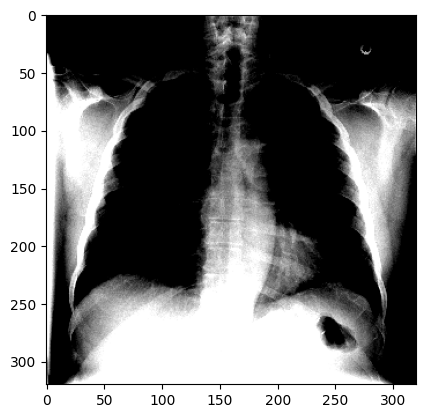

In [12]:
x, y = train_generator.__getitem__(0)
plt.imshow(x[0]);


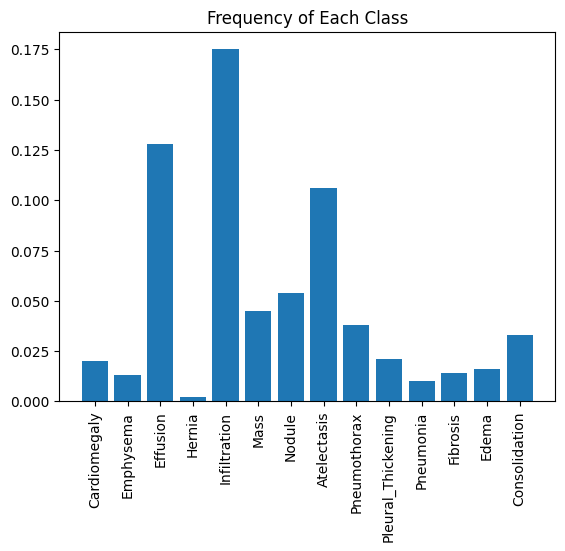

In [13]:
plt.xticks(rotation=90)
plt.bar(x=labels, height=np.mean(train_generator.labels, axis=0))
plt.title("Frequency of Each Class")
plt.show()

In [14]:
def compute_class_freqs(labels):
    """
    Compute positive and negative frequences for each class.

    Args:
        labels (np.array): matrix of labels, size (num_examples, num_classes)
    Returns:
        positive_frequencies (np.array): array of positive frequences for each
                                         class, size (num_classes)
        negative_frequencies (np.array): array of negative frequences for each
                                         class, size (num_classes)
    """
    # total number of patients (rows)
    N = labels.shape[0]

    positive_frequencies = np.sum(labels, axis = 0) / N
    negative_frequencies = 1 - positive_frequencies

    return positive_frequencies, negative_frequencies

In [15]:
# Test compute_class_freqs()
labels_matrix = np.array(
    [[1, 0, 0],
     [0, 1, 1],
     [1, 0, 1],
     [1, 1, 1],
     [1, 0, 1]]
)
print("labels:")

test_pos_freqs, test_neg_freqs = compute_class_freqs(labels_matrix)

print(f"pos freqs: {test_pos_freqs}")

print(f"neg freqs: {test_neg_freqs}")

labels:
pos freqs: [0.8 0.4 0.8]
neg freqs: [0.2 0.6 0.2]


In [16]:
freq_pos, freq_neg = compute_class_freqs(train_generator.labels)
freq_pos

array([0.02 , 0.013, 0.128, 0.002, 0.175, 0.045, 0.054, 0.106, 0.038,
       0.021, 0.01 , 0.014, 0.016, 0.033])

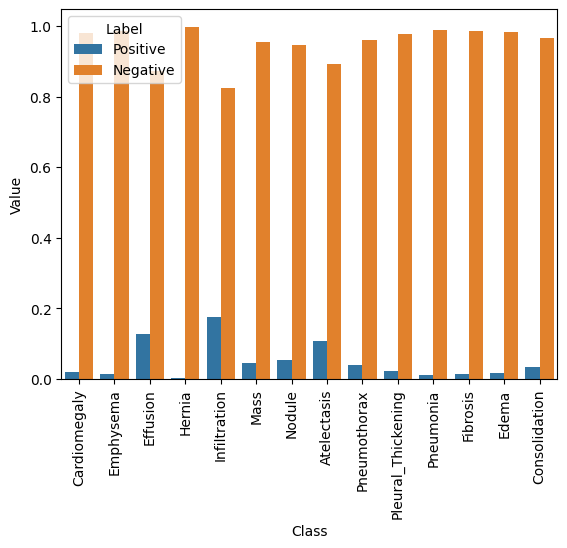

In [17]:
data = pd.DataFrame({"Class": labels, "Label": "Positive", "Value": freq_pos})
additional_data = pd.DataFrame([{"Class": labels[l], "Label": "Negative", "Value": v} for l, v in enumerate(freq_neg)])
data = pd.concat([data, additional_data], ignore_index=True)

plt.xticks(rotation=90)
f = sns.barplot(x="Class", y="Value", hue="Label", data=data)


In [18]:
pos_weights = freq_neg
neg_weights = freq_pos
pos_contribution = freq_pos * pos_weights
neg_contribution = freq_neg * neg_weights

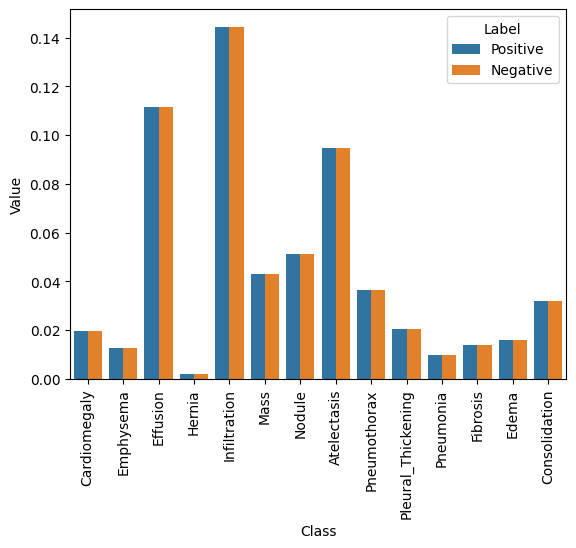

In [19]:
data = pd.DataFrame({"Class": labels, "Label": "Positive", "Value": pos_contribution})
data = pd.concat([data, pd.DataFrame([{"Class": labels[l], "Label": "Negative", "Value": v}
                    for l, v in enumerate(neg_contribution)])], ignore_index=True)

plt.xticks(rotation=90)
sns.barplot(x="Class", y="Value", hue="Label" ,data=data);

In [20]:
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    """
    Return weighted loss function given negative weights and positive weights.

    Args:
      pos_weights (np.array): array of positive weights for each class, size (num_classes)
      neg_weights (np.array): array of negative weights for each class, size (num_classes)

    Returns:
      weighted_loss (function): weighted loss function
    """
    def weighted_loss(y_true, y_pred):
        """
        Return weighted loss value.

        Args:
            y_true (Tensor): Tensor of true labels, size is (num_examples, num_classes)
            y_pred (Tensor): Tensor of predicted labels, size is (num_examples, num_classes)
        Returns:
            loss (Float): overall scalar loss summed across all classes
        """
        # initialize loss to zero
        loss = 0.0

        for i in range(len(pos_weights)):
            # for each class, we add average weighted loss for that class
            pos_loss = -1 * K.mean(pos_weights[i] * y_true[:, i] * K.log(y_pred[:, i] + epsilon))
            neg_loss = -1 * K.mean(neg_weights[i] * (1 - y_true[:, i]) * K.log(1 - y_pred[:, i] + epsilon))
            loss += pos_loss + neg_loss
        return loss

        ### END CODE HERE ###
    return weighted_loss

In [21]:
import numpy as np
from tensorflow.keras import backend as K
import tensorflow as tf

# Example get_weighted_loss function (make sure this is defined correctly in your code)
def get_weighted_loss(weights_positive, weights_negative, epsilon=1e-7):
    def weighted_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Avoiding log(0) by clipping values
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Calculating weighted loss
        loss_positive = -weights_positive * y_true * tf.math.log(y_pred)
        loss_negative = -weights_negative * (1 - y_true) * tf.math.log(1 - y_pred)

        return tf.reduce_mean(loss_positive + loss_negative)
    return weighted_loss

# Test get_weighted_loss()
print("Test example:\n")

y_true = tf.constant(np.array([
    [1, 1, 0],
    [0, 1, 0],
    [1, 0, 1]
]), dtype=tf.float32)

print("y_true:\n", y_true.numpy())

w_p = np.array([0.25, 0.25, 0.5])
w_n = np.array([0.75, 0.75, 0.5])
print("\nw_p:\n", w_p)
print("\nw_n:\n", w_n)

y_pred_1 = tf.constant(0.7 * np.ones(y_true.shape), dtype=tf.float32)
print("\ny_pred_1:\n", y_pred_1.numpy())

y_pred_2 = tf.constant(0.3 * np.ones(y_true.shape), dtype=tf.float32)
print("\ny_pred_2:\n", y_pred_2.numpy())

# Test with a large epsilon in order to catch errors
L = get_weighted_loss(w_p, w_n, epsilon=1)

print("\nIf we weighted them correctly, we expect the two losses to be the same.")
L1 = L(y_true, y_pred_1).numpy()
L2 = L(y_true, y_pred_2).numpy()
print(f"\nL(y_pred_1)= {L1:.4f}, L(y_pred_2)= {L2:.4f}")
print(f"Difference is L1 - L2 = {L1 - L2:.4f}")


Test example:

y_true:
 [[1. 1. 0.]
 [0. 1. 0.]
 [1. 0. 1.]]

w_p:
 [0.25 0.25 0.5 ]

w_n:
 [0.75 0.75 0.5 ]

y_pred_1:
 [[0.7 0.7 0.7]
 [0.7 0.7 0.7]
 [0.7 0.7 0.7]]

y_pred_2:
 [[0.3 0.3 0.3]
 [0.3 0.3 0.3]
 [0.3 0.3 0.3]]

If we weighted them correctly, we expect the two losses to be the same.

L(y_pred_1)= nan, L(y_pred_2)= nan
Difference is L1 - L2 = nan


In [22]:
# create the base pre-trained model
base_model = DenseNet121(weights='/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/densenet.hdf5', include_top=False)

x = base_model.output

# add a global spatial average pooling layer
x = GlobalAveragePooling2D()(x)

# and a logistic layer
predictions = Dense(len(labels), activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss=get_weighted_loss(pos_weights, neg_weights))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 813s 7s/step - loss: 0.0687 - val_loss: 0.6624
Epoch 2/3
 25/100 ━━━━━━━━━━━━━━━━━━━━ 8:35 7s/step - loss: 0.0613

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - loss: 0.0592 - val_loss: 0.4582
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 731s 7s/step - loss: 0.0565 - val_loss: 0.6103


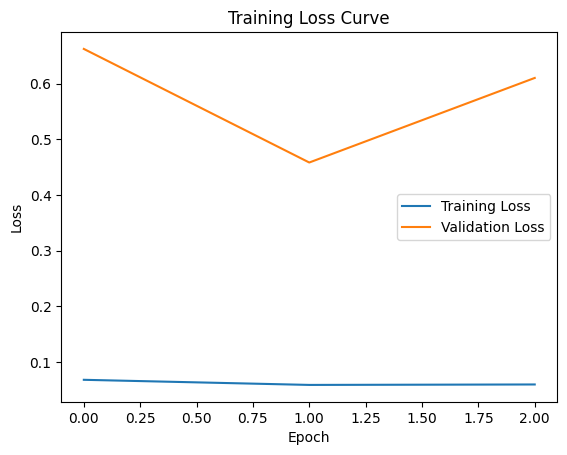

In [23]:
# Train the model using fit() instead of fit_generator()
history = model.fit(train_generator,
                    validation_data=valid_generator,
                    steps_per_epoch=100,
                    validation_steps=25,
                    epochs=3)

# Plot Training Loss Curve
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")  # Added validation loss
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.title("Training Loss Curve")
plt.legend()  # Show legend for clarity
plt.show()


In [24]:
model.load_weights("/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/pretrained_model.h5")

In [25]:
predicted_vals = model.predict(test_generator, steps=len(test_generator))


53/53 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step


In [26]:
import sys
sys.path.append('/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/')
import util


In [27]:
print(dir(util))  # This should list all functions including get_roc_curve


['INFO', 'K', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'compute_gradcam', 'cv2', 'get_mean_std_per_batch', 'get_roc_curve', 'grad_cam', 'image', 'load_image', 'np', 'plt', 'random', 'roc_auc_score', 'roc_curve', 'set_verbosity', 'tf']


/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/util.py:100: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/util.py:100: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/util.py:100: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/util.py:100: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
/content/drive/MyDrive/Chest-X-Ray-M

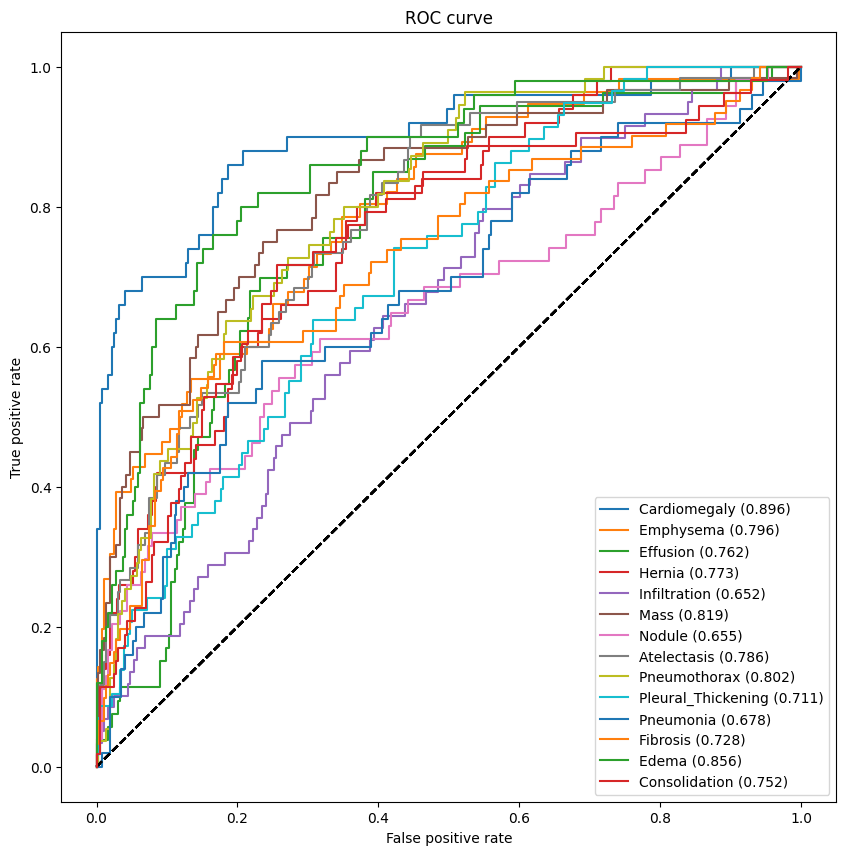

In [28]:
auc_rocs = util.get_roc_curve(labels, predicted_vals, test_generator)

In [29]:
df = pd.read_csv("/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/train-small.csv")
IMAGE_DIR = "/content/drive/MyDrive/Chest-X-Ray-Medical-Diagnosis-master/Chest-X-Ray-Medical-Diagnosis-master/nih/images-small/"

# only show the lables with top 4 AUC
labels_to_show = np.take(labels, np.argsort(auc_rocs)[::-1])[:4]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Loading original image
Generating gradcam for class Cardiomegaly


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 320, 320, 3))
  warnings.warn(msg)


Generating gradcam for class Mass
Generating gradcam for class Pneumothorax
Generating gradcam for class Edema


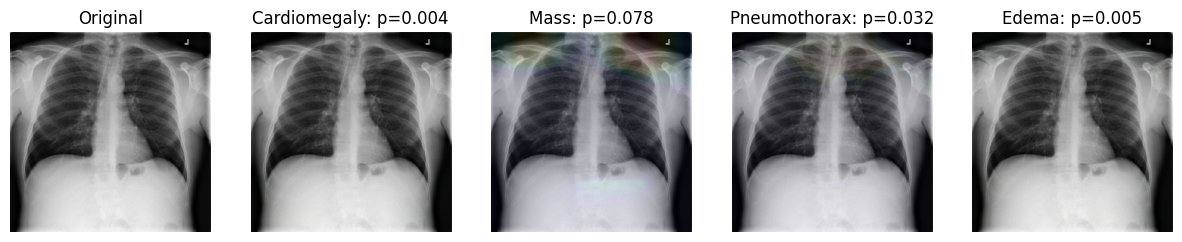

In [30]:
util.compute_gradcam(model, '00008270_015.png', IMAGE_DIR, df, labels, labels_to_show)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
Loading original image
Generating gradcam for class Cardiomegaly
Generating gradcam for class Mass
Generating gradcam for class Pneumothorax
Generating gradcam for class Edema


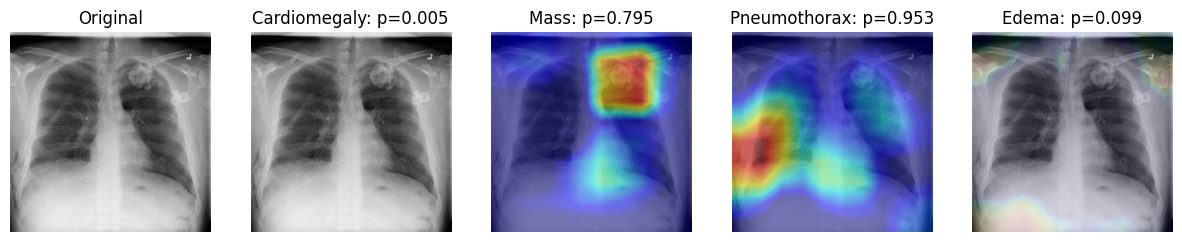

In [34]:
util.compute_gradcam(model, '00011355_002.png', IMAGE_DIR, df, labels, labels_to_show)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
Loading original image
Generating gradcam for class Cardiomegaly
Generating gradcam for class Mass
Generating gradcam for class Pneumothorax
Generating gradcam for class Edema


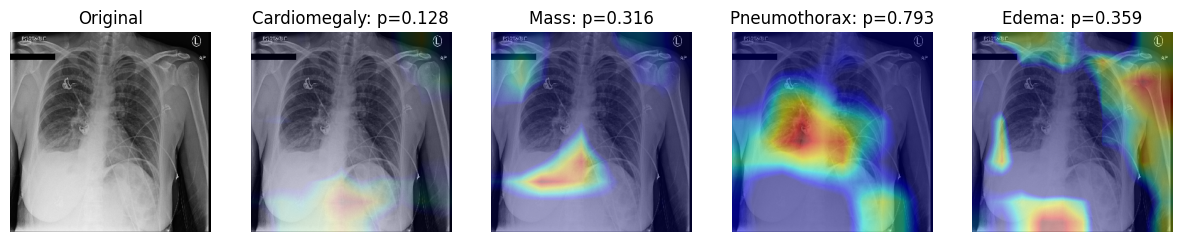

In [35]:
util.compute_gradcam(model, '00029855_001.png', IMAGE_DIR, df, labels, labels_to_show)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
Loading original image
Generating gradcam for class Cardiomegaly
Generating gradcam for class Mass
Generating gradcam for class Pneumothorax
Generating gradcam for class Edema


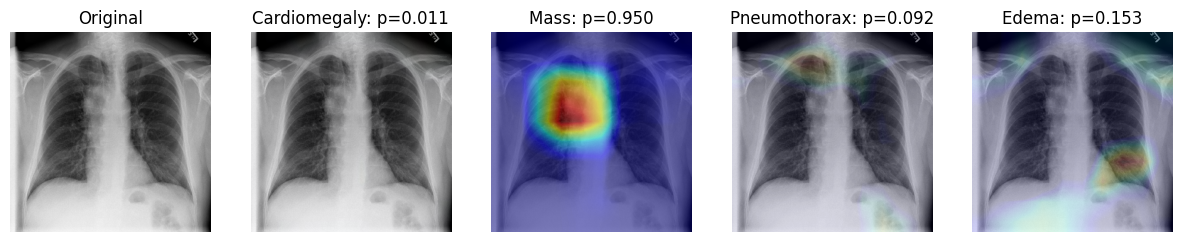

In [33]:
util.compute_gradcam(model, '00005410_000.png', IMAGE_DIR, df, labels, labels_to_show)